In [6]:
import pandas as pd
import numpy as np
from DATA.stock_invest_function import *
from sqlalchemy import create_engine, text

In [7]:
# DB 접속 정보 설정
db_info = {
    'user': 'stox7412',         # 예: 'root'
    'password': 'Apt106503!~', # 예: '1234'
    # 'host': '192.168.0.230',
    'host': get_db_host(),         # 예: 'localhost' 또는 IP
    'port': '3307',              # 기본 포트는 보통 3306
    'database': 'investar'        # 예: 'trade_data'
}

#### 1. 기존 제무제표 DATA IMPORT

In [34]:
target_ticker = 'GE'

# DB 엔진 생성 함수
def make_engine(db_info: dict):
    return create_engine(
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}",
        pool_pre_ping=True
    )

# ticker 데이터 조회 함수
def fetch_ticker_data(engine, table_name: str, ticker: str, ticker_col: str = "ticker") -> pd.DataFrame:
    sql = text(f"SELECT * FROM `{table_name}` WHERE `{ticker_col}` = :ticker")
    with engine.connect() as conn:
        df = pd.read_sql(sql, conn, params={"ticker": ticker})
    return df

# ===================== 사용 예시 =====================

engine = make_engine(db_info)

# 삼성전자 티커("A005930") 데이터 전부 가져오기
forecast_df = fetch_ticker_data(engine, table_name="us_fs_forecast_data", ticker=target_ticker)
print(df.head())

        date ticker  item         value  sales_billions  year
0 2004-03-31   AAPL  sale  1.909000e+09           1.909  2004
1 2004-06-30   AAPL  sale  2.014000e+09           2.014  2004
2 2004-09-30   AAPL  sale  2.350000e+09           2.350  2004
3 2004-12-31   AAPL  sale  3.490000e+09           3.490  2004
4 2005-03-31   AAPL  sale  3.243000e+09           3.243  2005


In [35]:
# 삼성전자 티커("A005930") 데이터 전부 가져오기
# historical_df = fetch_ticker_data(engine, table_name="'US_IS_from_FMP", ticker="AAPL")
## 미국 기업 재무정보
historical_df  = fetch_table_data(db_info, 'US_IS_from_FMP')

✅ 'US_IS_from_FMP' 테이블에서 6743738건의 데이터를 가져왔습니다.


In [36]:
extracted_df = historical_df[(historical_df['ticker'] == target_ticker) & (historical_df['fs_item'] == 'sale')]
extracted_resize_df = extracted_df[['date', 'ticker', 'fs_item', 'value']]
historical_fs_df = extracted_resize_df.rename(columns={'fs_item': 'item'})
historical_fs_df

,date,ticker,item,value
1092422,2004-03-31,GE,sale,3.359200e+10
1092444,2004-06-30,GE,sale,3.678100e+10
1092466,2004-09-30,GE,sale,3.833600e+10
1092488,2004-12-31,GE,sale,4.370600e+10
1092510,2005-03-31,GE,sale,3.435000e+10
...,...,...,...,...
1094204,2024-06-30,GE,sale,9.093000e+09
1094226,2024-09-30,GE,sale,9.842000e+09
1094248,2024-12-31,GE,sale,1.081100e+10
1094270,2025-03-31,GE,sale,9.934000e+09


In [37]:
df_filtered = forecast_df[forecast_df["target_col"] == "sale"].copy()
df_filtered["prediction_date"] = pd.to_datetime(df_filtered["prediction_date"])
forecast_fs_df = df_filtered[
    df_filtered["prediction_date"] == df_filtered["prediction_date"].max()
][['forecast_date', 'ticker', 'target_col', 'forecast_value']]
forecast_fs_df = forecast_fs_df.rename(columns={'forecast_date': 'date', 'target_col': 'item', 'forecast_value': 'value'})
forecast_fs_df

,date,ticker,item,value
0,2025-09-30,GE,sale,9.072828e+09
1,2025-12-31,GE,sale,1.624469e+10
2,2026-03-31,GE,sale,9.587287e+09
3,2026-06-30,GE,sale,1.025470e+10
4,2026-09-30,GE,sale,9.372824e+09
5,2026-12-31,GE,sale,1.280805e+10
6,2027-03-31,GE,sale,9.645877e+09
7,2027-06-30,GE,sale,1.058548e+10
8,2027-09-30,GE,sale,9.044537e+09
9,2027-12-31,GE,sale,1.476245e+10


정리된 데이터:
        date ticker  item         value
0 2004-03-31     GE  sale  3.359200e+10
1 2004-06-30     GE  sale  3.678100e+10
2 2004-09-30     GE  sale  3.833600e+10
3 2004-12-31     GE  sale  4.370600e+10
4 2005-03-31     GE  sale  3.435000e+10
5 2005-06-30     GE  sale  3.653900e+10
6 2005-09-30     GE  sale  3.636800e+10
7 2005-12-31     GE  sale  2.649300e+10
8 2006-03-31     GE  sale  3.802900e+10
9 2006-06-30     GE  sale  3.774500e+10

총 데이터 개수: 98
날짜 범위: 2004-03-31 00:00:00 ~ 2028-06-30 00:00:00
날짜 컬럼 타입: datetime64[ns]
DataFrame 컬럼명:
['date', 'ticker', 'item', 'value']

DataFrame 샘플:
        date ticker  item         value
0 2004-03-31     GE  sale  3.359200e+10
1 2004-06-30     GE  sale  3.678100e+10
2 2004-09-30     GE  sale  3.833600e+10
3 2004-12-31     GE  sale  4.370600e+10
4 2005-03-31     GE  sale  3.435000e+10
사용할 매출 컬럼: value

매출 통계:
최대 매출: $48.6B (2007-12-31)
최소 매출: $8.8B (2023-06-30)
평균 매출: $27.4B


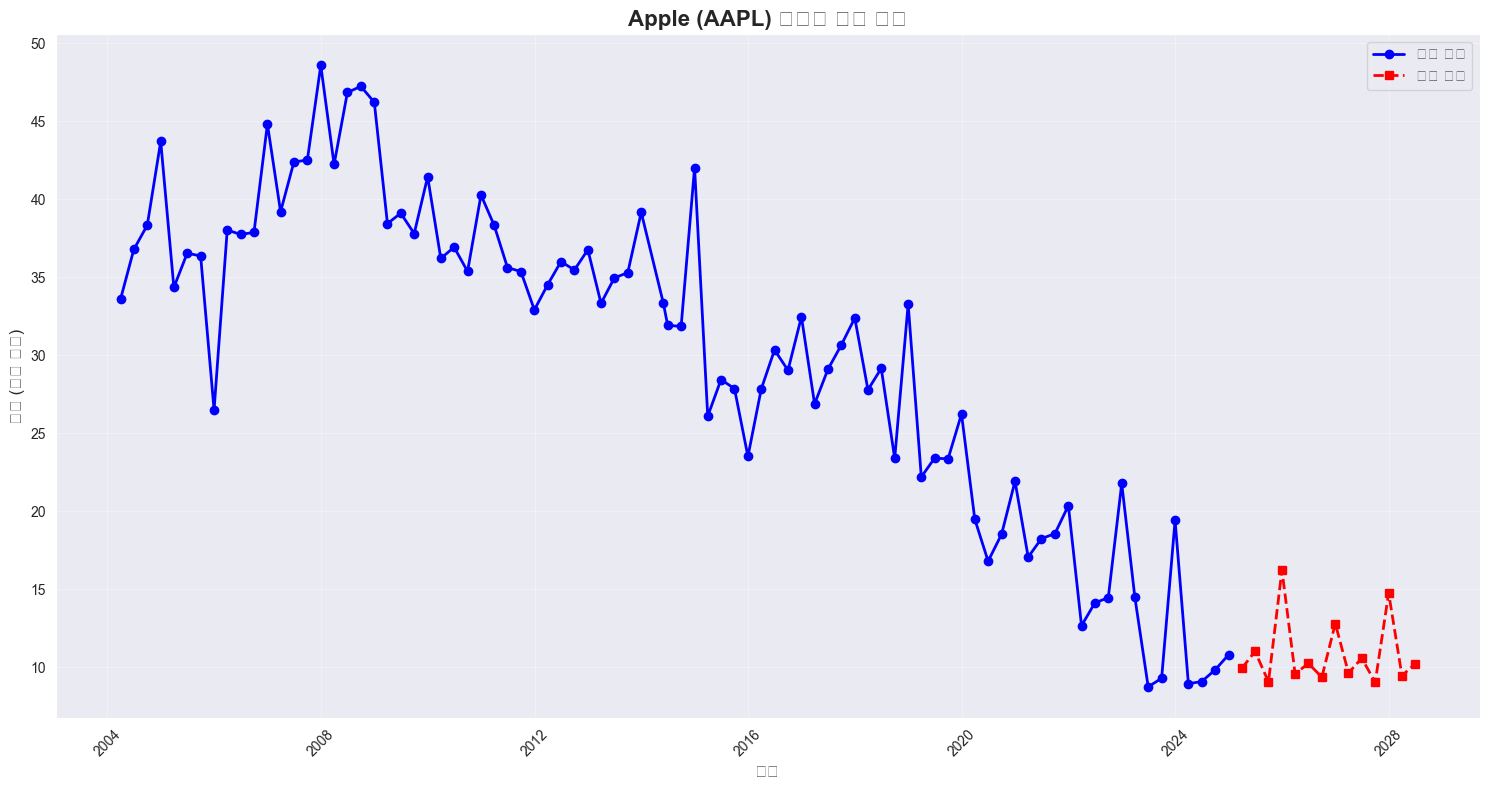


연도별 매출 합계 (십억 달러):
2004: $152.4B
2005: $133.8B
2006: $158.5B
2007: $172.7B
2008: $182.5B
2009: $156.8B
2010: $148.8B
2011: $142.2B
2012: $142.8B
2013: $142.7B
2014: $139.1B
2015: $105.9B
2016: $119.7B
2017: $119.0B
2018: $113.6B
2019: $95.2B
2020: $76.8B
2021: $74.3B
2022: $63.1B
2023: $52.0B
2024: $38.7B
2025: $46.3B
2026: $42.0B
2027: $44.0B
2028: $19.7B

날짜 컬럼 정보:
날짜 타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
첫 5개 날짜:
  2004-03-31 00:00:00 (타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>)
  2004-06-30 00:00:00 (타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>)
  2004-09-30 00:00:00 (타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>)
  2004-12-31 00:00:00 (타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>)
  2005-03-31 00:00:00 (타입: <class 'pandas._libs.tslibs.timestamps.Timestamp'>)


In [38]:
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

df = pd.concat([historical_fs_df, forecast_fs_df])

# 날짜 컬럼을 통일된 datetime 형태로 변환 (이 부분이 핵심!)
df['date'] = pd.to_datetime(df['date'])

# 날짜 순으로 정렬
df = df.sort_values('date').reset_index(drop=True)

# 데이터 확인
print("정리된 데이터:")
print(df.head(10))
print(f"\n총 데이터 개수: {len(df)}")
print(f"날짜 범위: {df['date'].min()} ~ {df['date'].max()}")
print(f"날짜 컬럼 타입: {df['date'].dtype}")

# 시각화
plt.figure(figsize=(15, 8))

# 컬럼명 확인 및 매출 컬럼 찾기
print("DataFrame 컬럼명:")
print(df.columns.tolist())
print("\nDataFrame 샘플:")
print(df.head())

# 가능한 매출 컬럼명들
possible_value_cols = ['forecast_value', 'value', 'sales', 'revenue', 'amount']
value_col = None

for col in possible_value_cols:
    if col in df.columns:
        value_col = col
        break

if value_col is None:
    # 숫자형 컬럼 중에서 찾기
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    if numeric_cols:
        value_col = numeric_cols[0]  # 첫 번째 숫자 컬럼 사용
        print(f"매출 컬럼을 '{value_col}'로 추정합니다.")
    else:
        raise ValueError("매출 데이터 컬럼을 찾을 수 없습니다. 컬럼명을 확인해주세요.")

print(f"사용할 매출 컬럼: {value_col}")

# 값을 십억 단위로 변환 (가독성 향상)
df['sales_billions'] = df[value_col] / 1e9

# 실제 데이터와 예측 데이터 구분 (2024년 말까지는 실제, 이후는 예측으로 가정)
actual_data = df[df['date'] <= '2024-12-31']
forecast_data = df[df['date'] > '2024-12-31']

# 플롯 생성
if len(actual_data) > 0:
    plt.plot(actual_data['date'], actual_data['sales_billions'],
             marker='o', linewidth=2, markersize=6, color='blue', label='실제 매출')

if len(forecast_data) > 0:
    plt.plot(forecast_data['date'], forecast_data['sales_billions'],
             marker='s', linewidth=2, markersize=6, color='red', linestyle='--', label='예측 매출')

# 그래프 꾸미기
plt.title('Apple (AAPL) 분기별 매출 추이', fontsize=16, fontweight='bold')
plt.xlabel('날짜', fontsize=12)
plt.ylabel('매출 (십억 달러)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# x축 날짜 포맷 조정
plt.xticks(rotation=45)
plt.tight_layout()

# 통계 정보 출력
print(f"\n매출 통계:")
max_value = df[value_col].max()
min_value = df[value_col].min()
max_date = df[df[value_col] == max_value]['date'].iloc[0]
min_date = df[df[value_col] == min_value]['date'].iloc[0]

print(f"최대 매출: ${max_value/1e9:.1f}B ({max_date.strftime('%Y-%m-%d')})")
print(f"최소 매출: ${min_value/1e9:.1f}B ({min_date.strftime('%Y-%m-%d')})")
print(f"평균 매출: ${df[value_col].mean()/1e9:.1f}B")

plt.show()

# 연도별 매출 합계
df['year'] = df['date'].dt.year
yearly_sales = df.groupby('year')[value_col].sum() / 1e9

print(f"\n연도별 매출 합계 (십억 달러):")
for year, sales in yearly_sales.items():
    print(f"{year}: ${sales:.1f}B")

# 데이터 확인용 - 날짜 타입 체크
print(f"\n날짜 컬럼 정보:")
print(f"날짜 타입: {type(df['date'].iloc[0])}")
print(f"첫 5개 날짜:")
for i in range(min(5, len(df))):
    print(f"  {df['date'].iloc[i]} (타입: {type(df['date'].iloc[i])})")

In [39]:
df_filtered["forecast_date"].max()

datetime.date(2028, 6, 30)